In [10]:
# 01.09.2026 - 20260901e.ipynb: KATALOG JAKO ZRODLO EFEKTU.
#
# Jeden watek: czy ~10-letni rytm minimow z Fig.4 da sie wyprodukowac z samego
# katalogu trzesien, bez zadnego zwiazku CR-EQ. Dwa niezalezne podejscia, oba
# tanie:
#
#  (1) PROG KOMPLETNOSCI. Katalog USGS przy M>=4.0 nie jest jednorodny w czasie -
#      rosnie liczba WYKRYWANYCH trzesien, bo rosnie siec sejsmometrow, a nie
#      sejsmicznosc. To jest wlasciwe zrodlo trendu w skladniku A (patrz
#      20260901c.ipynb). Wlasciwa naprawa nie jest statystyczna, tylko doborowa:
#      podniesc prog magnitudy do poziomu, przy ktorym katalog JEST jednorodny.
#      Prog wyznaczamy empirycznie - szukamy najnizszego progu, przy ktorym
#      tempo zdarzen na rok jest plaskie od 1965 do dzis.
#  (2) KATALOG SUROGATOWY. Budujemy sztuczny katalog, ktory zachowuje DOKLADNIE
#      roczne tempo i rozklad magnitud prawdziwego katalogu (czyli caly jego
#      trend detekcyjny), ale ma losowe czasy zdarzen w obrebie roku - czyli
#      zadnej realnej struktury sejsmicznej i tym samym zadnego mozliwego
#      zwiazku z promieniowaniem kosmicznym. Jesli skan po t0 na takim katalogu
#      odtworzy rytm minimow, to rytm pochodzi z trendu, a nie z trzesien.
#      To jest test konstrukcyjny: pokazuje mechanizm, zamiast go wnioskowac.
#
# KOSZT: trzy zgrubne skany po t0 dla samej Moskwy, krok 10 dni zamiast 6h
# (rytm ~10-letni nie wymaga rozdzielczosci podbinowej) - rzedu 2-4 minut.
# Wynik jest cache'owany razem z konfiguracja, jak w 20260901c.ipynb.
import json
import os

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom, norm

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"

P_DAYS, D_DAYS, DT_DAYS = 3350, 5, 15
T0_START = pd.Timestamp("1965-01-01 12:00")
T0_KONIEC = pd.Timestamp("2015-11-15 18:00")
KROK_SKANU_DNI = 10
ZIARNO = 20260901

katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog.sort_values("time").reset_index(drop=True)
print(f"Katalog USGS: {len(katalog)} zdarzen M>=4.0, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")

# KONTROLA POKRYCIA (blad wylapany 01.09 przez Macka, po pytaniu o wykres).
# Pierwsza wersja tego notebooka obcinala katalog na T0_KONIEC. To jest blad:
# okno ma P_DAYS dni PLUS lag DT_DAYS, wiec dla t0 blisko konca zakresu siega
# ono poza koniec katalogu i ostatnie kosze nie maja zadnych trzesien (Sm=0),
# przez co wypadaja z maski waznosci. W obcietej wersji mediana N_valid spadala
# w tej strefie z 666 do 337, a maksimum krzywej dla M>=5.5 wypadalo wlasnie
# tam - czyli bylo artefaktem, a nie wynikiem.
# Teraz: katalog jest pelny, a zakres skanu przycinamy do t0, dla ktorych CALE
# okno miesci sie w katalogu. Warunek jest sprawdzany, nie zakladany.
T0_MAX_POKRYTY = katalog["time"].max() - pd.Timedelta(days=P_DAYS + DT_DAYS)
if T0_KONIEC > T0_MAX_POKRYTY:
    print(f"UWAGA: katalog konczy sie {katalog['time'].max().date()}, wiec okno "
          f"{P_DAYS}+{DT_DAYS} dni miesci sie tylko dla t0 <= {T0_MAX_POKRYTY.date()}.")
    print(f"Zakres skanu przyciety z {T0_KONIEC.date()} do {T0_MAX_POKRYTY.date()}.")
    T0_KONIEC = T0_MAX_POKRYTY
else:
    print(f"Pokrycie katalogu OK: okno miesci sie dla kazdego t0 do {T0_KONIEC.date()}.")


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def cosmoseismic_stat(cr, eq, t0, P_days=P_DAYS, d_days=D_DAYS, dt_days=DT_DAYS):
    # przepisane 1:1 z 20260826/20260826d.ipynb, komorka 0
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)
    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_vals = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories).to_numpy()
    w = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(w.index, eq_edges, right=False)
    sm_vals = w.groupby(eq_cats, observed=False).sum().reindex(
        eq_cats.categories, fill_value=0.0).to_numpy()
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    Np, Nm = int((c > 0).sum()), int((c < 0).sum())
    n = Np + Nm
    if n == 0:
        return dict(N_valid=0, Np=0, PPDF=np.nan, sigma=np.nan)
    return dict(N_valid=n, Np=Np, PPDF=binom.pmf(Np, n, 0.5),
                sigma=float(norm.isf(binom.sf(Np - 1, n, 0.5))))


cr_mosc = load_mosc()
print(f"CR Moskwa: {len(cr_mosc)} pomiarow 6h, "
      f"{cr_mosc.index.min().date()} .. {cr_mosc.index.max().date()}")


Katalog USGS: 507920 zdarzen M>=4.0, 1965-01-01 .. 2025-01-31
Pokrycie katalogu OK: okno miesci sie dla kazdego t0 do 2015-11-15.
CR Moskwa: 91824 pomiarow 6h, 1960-01-01 .. 2025-03-23


In [11]:
# KROK 1: prog kompletnosci katalogu. Dla kilku progow magnitudy liczymy tempo
# zdarzen na rok i porownujemy dekade 2005-2014 z dekada 1970-1979. Stosunek
# blisko 1 oznacza katalog jednorodny w czasie; stosunek duzo wiekszy od 1 to
# przyrost DETEKCJI, nie sejsmicznosci (globalna siec sejsmiczna rosla przez
# cala te epoke).
#
# Uwaga interpretacyjna: przy bardzo wysokich progach stosunek moze znowu
# odbiegac od 1, ale juz z innego powodu - realnej zmiennosci globalnej
# sejsmicznosci w skali dekad (np. seria wielkich trzesien 2004-2011:
# Sumatra, Chile, Tohoku). Szukamy wiec minimum tego stosunku, a nie po prostu
# najwyzszego progu.
PROGI = [4.0, 4.5, 5.0, 5.5, 6.0]

wiersze = []
for m in PROGI:
    s = katalog[katalog["mag"] >= m]
    r_stare = len(s[(s["time"] >= "1970") & (s["time"] < "1980")]) / 10
    r_nowe = len(s[(s["time"] >= "2005") & (s["time"] < "2015")]) / 10
    wiersze.append(dict(prog_M=m, zdarzen=len(s), tempo_1970_79=r_stare,
                        tempo_2005_14=r_nowe, stosunek=r_nowe / r_stare,
                        zdarzen_na_bin_5d=r_nowe / 365.25 * D_DAYS))

kompletnosc = pd.DataFrame(wiersze)
kompletnosc.to_csv(f"{RESULTS_DIR}/katalog_kompletnosc.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/katalog_kompletnosc.csv")
print()
print(kompletnosc.round(2).to_string(index=False))

M_KOMPLETNY = float(kompletnosc.loc[kompletnosc["stosunek"].idxmin(), "prog_M"])
print()
print(f"Prog o najbardziej plaskim tempie: M >= {M_KOMPLETNY}")
print("To jest prog, przy ktorym trend detekcyjny w skladniku A praktycznie")
print("znika - i przy ktorym warto powtorzyc caly rachunek artykulu.")


Zapisano ../results/katalog_kompletnosc.csv

 prog_M  zdarzen  tempo_1970_79  tempo_2005_14  stosunek  zdarzen_na_bin_5d
    4.0   507919         3209.4        14007.0      4.36             191.75
    4.5   285721         2584.3         7411.9      2.87             101.46
    5.0    91893         1358.1         2020.2      1.49              27.66
    5.5    28325          437.7          532.7      1.22               7.29
    6.0     8342          112.7          164.9      1.46               2.26

Prog o najbardziej plaskim tempie: M >= 5.5
To jest prog, przy ktorym trend detekcyjny w skladniku A praktycznie
znika - i przy ktorym warto powtorzyc caly rachunek artykulu.


Lata rysowane: 1965-2024
Pominieto lata niepelne (pokrycie < 99% zakresu katalogu): [2025]
Zapisano ../results/katalog_kompletnosc.png


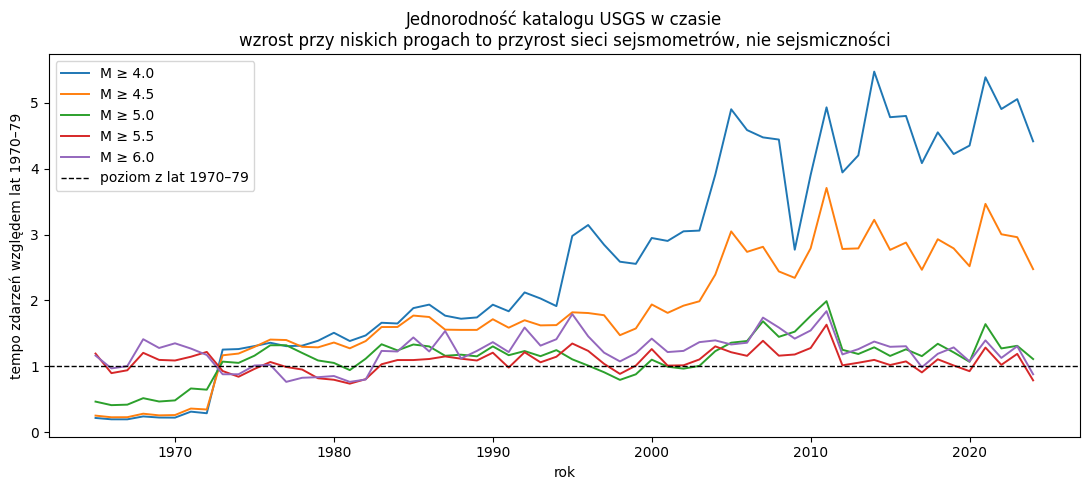

In [12]:
# Wykres 1 (jedno kodowanie: wysokosc krzywej): tempo zdarzen na rok dla
# kolejnych progow magnitudy, kazda krzywa znormalizowana do swojej sredniej
# z lat 1970-1979. Krzywa plaska = katalog jednorodny; krzywa rosnaca = przyrost
# detekcji.
import matplotlib.pyplot as plt

# Lata niepelne na brzegach zakresu katalogu daja sztuczne zalamanie krzywej:
# katalog konczy sie 2025-01-31, wiec slupek za 2025 obejmuje jeden miesiac i
# spada niemal do zera. To artefakt rysowania, a nie wlasnosc katalogu (blad
# pierwszej wersji tego wykresu, wylapany 01.09 przez Macka). Rysujemy tylko
# lata pokryte przez katalog w co najmniej 99%.
poczatek_kat, koniec_kat = katalog["time"].min(), katalog["time"].max()


def pokrycie_roku(rok):
    start = pd.Timestamp(year=rok, month=1, day=1)
    stop = pd.Timestamp(year=rok + 1, month=1, day=1)
    objete = (min(stop, koniec_kat) - max(start, poczatek_kat)).total_seconds()
    return max(0.0, objete) / (stop - start).total_seconds()


LATA_PELNE = [r for r in range(poczatek_kat.year, koniec_kat.year + 1)
              if pokrycie_roku(r) >= 0.99]
pominiete = [r for r in range(poczatek_kat.year, koniec_kat.year + 1)
             if r not in LATA_PELNE]
print(f"Lata rysowane: {LATA_PELNE[0]}-{LATA_PELNE[-1]}")
if pominiete:
    print(f"Pominieto lata niepelne (pokrycie < 99% zakresu katalogu): {pominiete}")

fig, ax = plt.subplots(figsize=(11, 5))
for m in PROGI:
    s = katalog[katalog["mag"] >= m].set_index("time")
    rocznie = s.resample("YE").size()
    rocznie.index = rocznie.index.year
    rocznie = rocznie.reindex(LATA_PELNE)
    baza = rocznie.loc[1970:1979].mean()
    ax.plot(rocznie.index, rocznie / baza, lw=1.4, label=f"M ≥ {m}")
ax.axhline(1.0, color="black", lw=1, ls="--", label="poziom z lat 1970–79")
ax.set_xlabel("rok")
ax.set_ylabel("tempo zdarzeń względem lat 1970–79")
ax.set_title("Jednorodność katalogu USGS w czasie\n"
             "wzrost przy niskich progach to przyrost sieci sejsmometrów, nie sejsmiczności")
ax.legend()
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/katalog_kompletnosc.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/katalog_kompletnosc.png")


In [13]:
# KROK 1c: powiazanie kompletnosci katalogu z KONKRETNYMI erami. Wykres wyzej
# pokazuje trend w skali calego katalogu, ale statystyka artykulu nie widzi
# calego katalogu - widzi jedno okno 3350 dni na raz. Pytanie brzmi wiec: jak
# stromy jest trend WEWNATRZ okna kazdej z pieciu er? Bo to on, a nie trend
# globalny, tworzy blokowy uklad znakow skladnika A (patrz 20260901c.ipynb).
#
# Miara: stosunek tempa zdarzen w OSTATNIM roku okna do tempa w PIERWSZYM roku
# tego samego okna. Wartosc 1 = katalog w tym oknie jednorodny; wartosc 5 =
# piec razy wiecej wykrywanych zdarzen na koncu okna niz na poczatku.
# Centra er brane z results/section4_network_minima.csv (Watek 1, 31.08), zeby
# byly te same, ktorych uzywaja wszystkie pozostale notebooki.
minima_sieci = pd.read_csv(f"{RESULTS_DIR}/section4_network_minima.csv",
                            parse_dates=["t0_h5"])
centra = (minima_sieci[minima_sieci["matched_h5"]].groupby("era")["t0_h5"].median())
ERY_GLOWNE = [1968, 1978, 1988, 1999, 2008]

wiersze_er = []
for era in ERY_GLOWNE:
    t0 = centra[era]
    t1 = t0 + pd.Timedelta(days=P_DAYS)
    rekord = dict(era=era, okno_start=t0.date(), okno_koniec=t1.date())
    for m in [4.0, M_KOMPLETNY]:
        s = katalog[katalog["mag"] >= m]
        pierwszy = len(s[(s["time"] >= t0) & (s["time"] < t0 + pd.Timedelta(days=365))])
        ostatni = len(s[(s["time"] >= t1 - pd.Timedelta(days=365)) & (s["time"] < t1)])
        rekord[f"przyrost_M{m}"] = ostatni / pierwszy if pierwszy else np.nan
        rekord[f"zdarzen_1szy_rok_M{m}"] = pierwszy
    wiersze_er.append(rekord)

przyrost_w_erach = pd.DataFrame(wiersze_er)
przyrost_w_erach.to_csv(f"{RESULTS_DIR}/katalog_przyrost_w_erach.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/katalog_przyrost_w_erach.csv")
print()
print("Przyrost tempa katalogu WEWNATRZ okna 3350 dni kazdej ery")
print("(tempo w ostatnim roku okna / tempo w pierwszym roku okna):")
print(przyrost_w_erach.round(2).to_string(index=False))
print()
print("Czytanie: im wieksza liczba przy M>=4.0, tym silniejszy trend detekcyjny")
print("w oknie tej ery, a wiec tym latwiej o blokowy uklad znakow skladnika A.")
print("Kolumna dla progu kompletnosci pokazuje, ile z tego przyrostu zostaje,")
print("gdy katalog jest jednorodny.")


Zapisano ../results/katalog_przyrost_w_erach.csv

Przyrost tempa katalogu WEWNATRZ okna 3350 dni kazdej ery
(tempo w ostatnim roku okna / tempo w pierwszym roku okna):
 era okno_start okno_koniec  przyrost_M4.0  zdarzen_1szy_rok_M4.0  przyrost_M5.5  zdarzen_1szy_rok_M5.5
1968 1968-06-30  1977-09-01           5.77                    704           0.80                    483
1978 1978-05-23  1987-07-25           1.38                   4213           1.41                    361
1988 1988-12-08  1998-02-09           1.67                   5522           1.03                    463
1999 1999-03-22  2008-05-23           1.82                   7873           1.21                    454
2008 2008-10-20  2017-12-22           1.32                   9992           0.76                    523

Czytanie: im wieksza liczba przy M>=4.0, tym silniejszy trend detekcyjny
w oknie tej ery, a wiec tym latwiej o blokowy uklad znakow skladnika A.
Kolumna dla progu kompletnosci pokazuje, ile z tego przyrostu 

In [14]:
# KROK 2: katalog surogatowy. Dla kazdego roku bierzemy DOKLADNIE tyle zdarzen,
# ile bylo naprawde, i DOKLADNIE te magnitudy (losowane ze zwracaniem z tego
# samego roku) - ale czasy zdarzen losujemy jednostajnie w obrebie roku.
#
# Co to zachowuje: roczne tempo (czyli caly trend detekcyjny) i rozklad magnitud,
# rok po roku.
# Co to niszczy: wszelka strukture czasowa w skali krotszej niz rok - grupowanie
# wstrzasow wtornych, sezonowosc, i przede wszystkim jakikolwiek mozliwy zwiazek
# z promieniowaniem kosmicznym.
#
# Jesli skan po t0 na tym katalogu odtworzy rytm minimow, to rytm nie moze
# pochodzic od trzesien - bo tu zadnej realnej struktury trzesien juz nie ma.
# LICZBA REALIZACJI. Jedna realizacja surogatu nie wystarczy: powiedzialaby
# tylko "pewien losowy katalog zrobil to a to", a nie "katalogi o tym trendzie
# TYPOWO to robia". Liczymy kilka niezaleznych realizacji i patrzymy na rozrzut.
# Kazda kosztuje jeden skan (~1 min), wiec 3 to rozsadny kompromis.
N_SUROGATOW = 3


def zbuduj_surogat(ziarno):
    rng = np.random.default_rng(ziarno)
    czesci = []
    for rok, grupa in katalog.groupby(katalog["time"].dt.year):
        n = len(grupa)
        poczatek = pd.Timestamp(year=int(rok), month=1, day=1)
        dlugosc = (pd.Timestamp(year=int(rok) + 1, month=1, day=1) - poczatek).total_seconds()
        czasy = poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s")
        magnitudy = rng.choice(grupa["mag"].to_numpy(), size=n, replace=True)
        czesci.append(pd.DataFrame(dict(time=czasy, mag=magnitudy)))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    # Losowane czasy maja rozdzielczosc nanosekundowa, a krawedzie koszy
    # (pd.date_range) mikrosekundowa - pd.cut nie potrafi tego bezstratnie
    # porownac i rzuca wyjatkiem. Zaokraglamy do pelnych sekund; przy koszach
    # 5-dniowych to bez znaczenia.
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


surogaty = [zbuduj_surogat(ZIARNO + i) for i in range(N_SUROGATOW)]

# KATALOG PRZERZEDZONY - kontrola do wyniku dla progu kompletnosci. Podniesienie
# progu do M>=5.5 zmienia NARAZ dwie rzeczy: usuwa trend detekcyjny (o to nam
# chodzilo), ale takze zmniejsza liczbe zdarzen na kosz z ~192 do ~7. Gdyby
# minima znikaly z tego drugiego powodu (rzadszy katalog = bardziej szumiace
# Sm = slabszy sygnal), wniosek o jednorodnosci bylby bledny.
# Rozdzielamy te dwie rzeczy: bierzemy katalog M>=4.0 i losowo wyrzucamy z niego
# zdarzenia tak, zeby zostalo ich tyle samo, co przy M>=5.5. Losowanie jednostajne
# po calym katalogu zachowuje KSZTALT tempa w czasie (a wiec caly trend
# detekcyjny) i zmienia tylko gestosc. Jesli ten katalog nadal daje minima, to
# znaczy, ze zanik przy M>=5.5 bierze sie z jednorodnosci, a nie z rzadkosci.
n_kompletny = int((katalog["mag"] >= M_KOMPLETNY).sum())
frakcja = n_kompletny / len(katalog)
rng_przerz = np.random.default_rng(ZIARNO + 100)
maska = rng_przerz.random(len(katalog)) < frakcja
przerzedzony = katalog[maska].reset_index(drop=True)
print()
print(f"Katalog przerzedzony: {len(przerzedzony)} zdarzen (cel: {n_kompletny}, "
      f"czyli tyle co przy M>={M_KOMPLETNY}), frakcja zachowana {frakcja:.4f}")
print(f"  kontrola trendu - stosunek tempa 2005-2014 do 1970-1979:")
for nazwa, kat in [("pelny M>=4.0", katalog), ("przerzedzony", przerzedzony),
                   (f"M>={M_KOMPLETNY}", katalog[katalog["mag"] >= M_KOMPLETNY])]:
    r1 = len(kat[(kat["time"] >= "1970") & (kat["time"] < "1980")]) / 10
    r2 = len(kat[(kat["time"] >= "2005") & (kat["time"] < "2015")]) / 10
    print(f"    {nazwa:16s} {r2 / r1:.2f}")

for i, s in enumerate(surogaty):
    kontrola = pd.DataFrame({
        "prawdziwy": katalog.groupby(katalog["time"].dt.year).size(),
        "surogat": s.groupby(s["time"].dt.year).size(),
    })
    roznica = (kontrola["surogat"] - kontrola["prawdziwy"]).abs().max()
    print(f"surogat {i + 1}: {len(s)} zdarzen, najwieksza roznica rocznej liczby "
          f"zdarzen = {roznica} (ma byc 0), srednia magnituda {s['mag'].mean():.4f} "
          f"wobec {katalog['mag'].mean():.4f} w prawdziwym")



Katalog przerzedzony: 28689 zdarzen (cel: 28325, czyli tyle co przy M>=5.5), frakcja zachowana 0.0558
  kontrola trendu - stosunek tempa 2005-2014 do 1970-1979:
    pelny M>=4.0     4.36
    przerzedzony     4.22
    M>=5.5           1.22
surogat 1: 507920 zdarzen, najwieksza roznica rocznej liczby zdarzen = 0 (ma byc 0), srednia magnituda 4.6009 wobec 4.6015 w prawdziwym
surogat 2: 507920 zdarzen, najwieksza roznica rocznej liczby zdarzen = 0 (ma byc 0), srednia magnituda 4.6009 wobec 4.6015 w prawdziwym
surogat 3: 507920 zdarzen, najwieksza roznica rocznej liczby zdarzen = 0 (ma byc 0), srednia magnituda 4.6012 wobec 4.6015 w prawdziwym


In [15]:
# KROK 3: zgrubne skany po t0 dla Moskwy, po jednym na kazda wersje katalogu:
#   (a) prawdziwy M>=4.0         - odniesienie, tak liczy artykul
#   (b) prawdziwy M>=M_KOMPLETNY - jednorodny w czasie, ale rzadki
#   (c) przerzedzony M>=4.0      - rownie rzadki, ale z zachowanym trendem
#                                  (kontrola: jednorodnosc czy rzadkosc?)
#   (d) 3 x surogat M>=4.0       - pelna gestosc, sam trend, zero struktury
#                                  czasowej trzesien
# Krok skanu 10 dni (nie 6h) - szukamy rytmu ~10-letniego, nie pojedynczego
# punktu, wiec rozdzielczosc podbinowa jest tu niepotrzebna i pieciokrotnie
# by wydluzyla rachunek.
import time

SCIEZKA_SKANU = f"{RESULTS_DIR}/surogat_skan_mosc.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/surogat_skan_mosc_config.json"
PRZELICZ_OD_NOWA = False


def biezaca_konfiguracja():
    # Do konfiguracji wchodzi tez ZAKRES KATALOGU. Bez tego poprawka z 01.09
    # (zdjecie obciecia katalogu na T0_KONIEC) nie zmienilaby zadnego pola
    # konfiguracji, wiec guard wpuscilby stary, obliczony na obcietym katalogu
    # plik jako aktualny - dokladnie ten sam rodzaj cichej pomylki, przed ktora
    # ten mechanizm ma chronic.
    return dict(P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                KROK_SKANU_DNI=KROK_SKANU_DNI, ZIARNO=ZIARNO,
                N_SUROGATOW=N_SUROGATOW, M_KOMPLETNY=M_KOMPLETNY,
                T0_START=str(T0_START), T0_KONIEC=str(T0_KONIEC),
                katalog_n=int(len(katalog)),
                katalog_zakres=[str(katalog["time"].min()), str(katalog["time"].max())])


siatka_t0 = pd.date_range(T0_START, T0_KONIEC, freq=pd.Timedelta(days=KROK_SKANU_DNI))
WERSJE = [("prawdziwy_M4", katalog, 4.0),
          (f"prawdziwy_M{M_KOMPLETNY}", katalog, M_KOMPLETNY),
          ("przerzedzony_M4", przerzedzony, 4.0)]
WERSJE += [(f"surogat{i + 1}_M4", s, 4.0) for i, s in enumerate(surogaty)]
NAZWY_SUROGATOW = [f"surogat{i + 1}_M4" for i in range(N_SUROGATOW)]

wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_SKANU) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == biezaca_konfiguracja():
        skan = pd.read_csv(SCIEZKA_SKANU, parse_dates=["t0"])
        if set(skan["wersja"].unique()) == {w[0] for w in WERSJE} and \
           len(skan) == len(siatka_t0) * len(WERSJE):
            wczytano = True
            print(f"WCZYTANO gotowy skan z {SCIEZKA_SKANU} ({len(skan)} wierszy) - nic nie liczono.")
    if not wczytano:
        print("Zapisany skan nie pasuje do biezacej konfiguracji - liczymy od nowa.")

if not wczytano:
    print(f"Skan: {len(siatka_t0)} punktow t0 x {len(WERSJE)} wersji katalogu")
    start = time.time()
    rekordy = []
    for nazwa, kat, prog in WERSJE:
        eq = kat[kat["mag"] >= prog].set_index("time")["mag"].sort_index()
        for i, t0 in enumerate(siatka_t0):
            s = cosmoseismic_stat(cr_mosc, eq, t0)
            rekordy.append(dict(wersja=nazwa, t0=t0, PPDF=s["PPDF"],
                                sigma=s["sigma"], N_valid=s["N_valid"]))
        print(f"  {nazwa}: gotowe, {time.time() - start:.0f} s")
    skan = pd.DataFrame(rekordy)
    skan["neglog10_PPDF"] = -np.log10(skan["PPDF"])
    skan.to_csv(SCIEZKA_SKANU, index=False)
    json.dump(biezaca_konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_SKANU} i {SCIEZKA_KONFIG}, czas {time.time() - start:.0f} s")

print()
print(skan.groupby("wersja")[["neglog10_PPDF", "N_valid"]].describe().round(2).to_string())


WCZYTANO gotowy skan z ../results/surogat_skan_mosc.csv (11154 wierszy) - nic nie liczono.

                neglog10_PPDF                                            N_valid                                                  
                        count  mean   std   min   25%   50%   75%    max   count    mean    std    min    25%    50%    75%    max
wersja                                                                                                                            
prawdziwy_M4           1859.0  2.56  1.25  1.51  1.63  1.96  3.34   6.79  1859.0  665.22   5.16  638.0  665.0  667.0  667.0  668.0
prawdziwy_M5.5         1859.0  1.74  0.29  1.50  1.53  1.59  1.85   3.12  1859.0  659.41   5.04  634.0  659.0  661.0  662.0  665.0
przerzedzony_M4        1859.0  1.86  0.43  1.44  1.57  1.71  1.93   3.87  1859.0  629.78  78.11  299.0  649.0  661.0  664.0  667.0
surogat1_M4            1859.0  2.72  1.19  1.50  1.75  2.42  3.34   6.79  1859.0  665.17   5.16  638.0  665.0  667.0  667.

In [16]:
# KROK 4: detekcja minimow na KAZDEJ z krzywych, tym samym kryterium co
# 31.08 (find_peaks na -log10 PPDF, prog 5.0, nienakladajace sie okna 3350 dni).
PROG_WYSOKOSCI = 5.0
DISTANCE = int(round(P_DAYS / KROK_SKANU_DNI))

znalezione = {}
for nazwa, _, _ in WERSJE:
    krzywa = skan[skan["wersja"] == nazwa].sort_values("t0").reset_index(drop=True)
    y = krzywa["neglog10_PPDF"].to_numpy()
    piki, _ = find_peaks(y, height=PROG_WYSOKOSCI, distance=DISTANCE)
    znalezione[nazwa] = krzywa.iloc[piki]
    daty = krzywa["t0"].iloc[piki]
    odstepy = daty.diff().dt.days.dropna() / 365.25
    print(f"{nazwa}:")
    print(f"  minimow powyzej progu {PROG_WYSOKOSCI}: {len(piki)}")
    if len(piki):
        print(f"  najglebsze: -log10 PPDF = {y[piki].max():.2f}")
        print(f"  daty: {', '.join(str(d.date()) for d in daty)}")
    if len(odstepy):
        print(f"  odstepy miedzy minimami [lata]: "
              f"{', '.join(f'{o:.1f}' for o in odstepy)}  (mediana {odstepy.median():.1f})")
    print()


prawdziwy_M4:
  minimow powyzej progu 5.0: 4
  najglebsze: -log10 PPDF = 6.79
  daty: 1968-05-25, 1978-06-02, 1998-08-16, 2008-09-12
  odstepy miedzy minimami [lata]: 10.0, 20.2, 10.1  (mediana 10.1)

prawdziwy_M5.5:
  minimow powyzej progu 5.0: 0

przerzedzony_M4:
  minimow powyzej progu 5.0: 0

surogat1_M4:
  minimow powyzej progu 5.0: 3
  najglebsze: -log10 PPDF = 6.79
  daty: 1968-05-15, 1978-11-19, 1988-08-18
  odstepy miedzy minimami [lata]: 10.5, 9.7  (mediana 10.1)

surogat2_M4:
  minimow powyzej progu 5.0: 4
  najglebsze: -log10 PPDF = 10.90
  daty: 1967-03-22, 1978-03-24, 1989-03-06, 2008-01-06
  odstepy miedzy minimami [lata]: 11.0, 11.0, 18.8  (mediana 11.0)

surogat3_M4:
  minimow powyzej progu 5.0: 4
  najglebsze: -log10 PPDF = 7.30
  daty: 1968-09-12, 1978-10-30, 1988-08-18, 2014-03-25
  odstepy miedzy minimami [lata]: 10.1, 9.8, 25.6  (mediana 10.1)



Zapisano ../results/surogat_skan_mosc.png


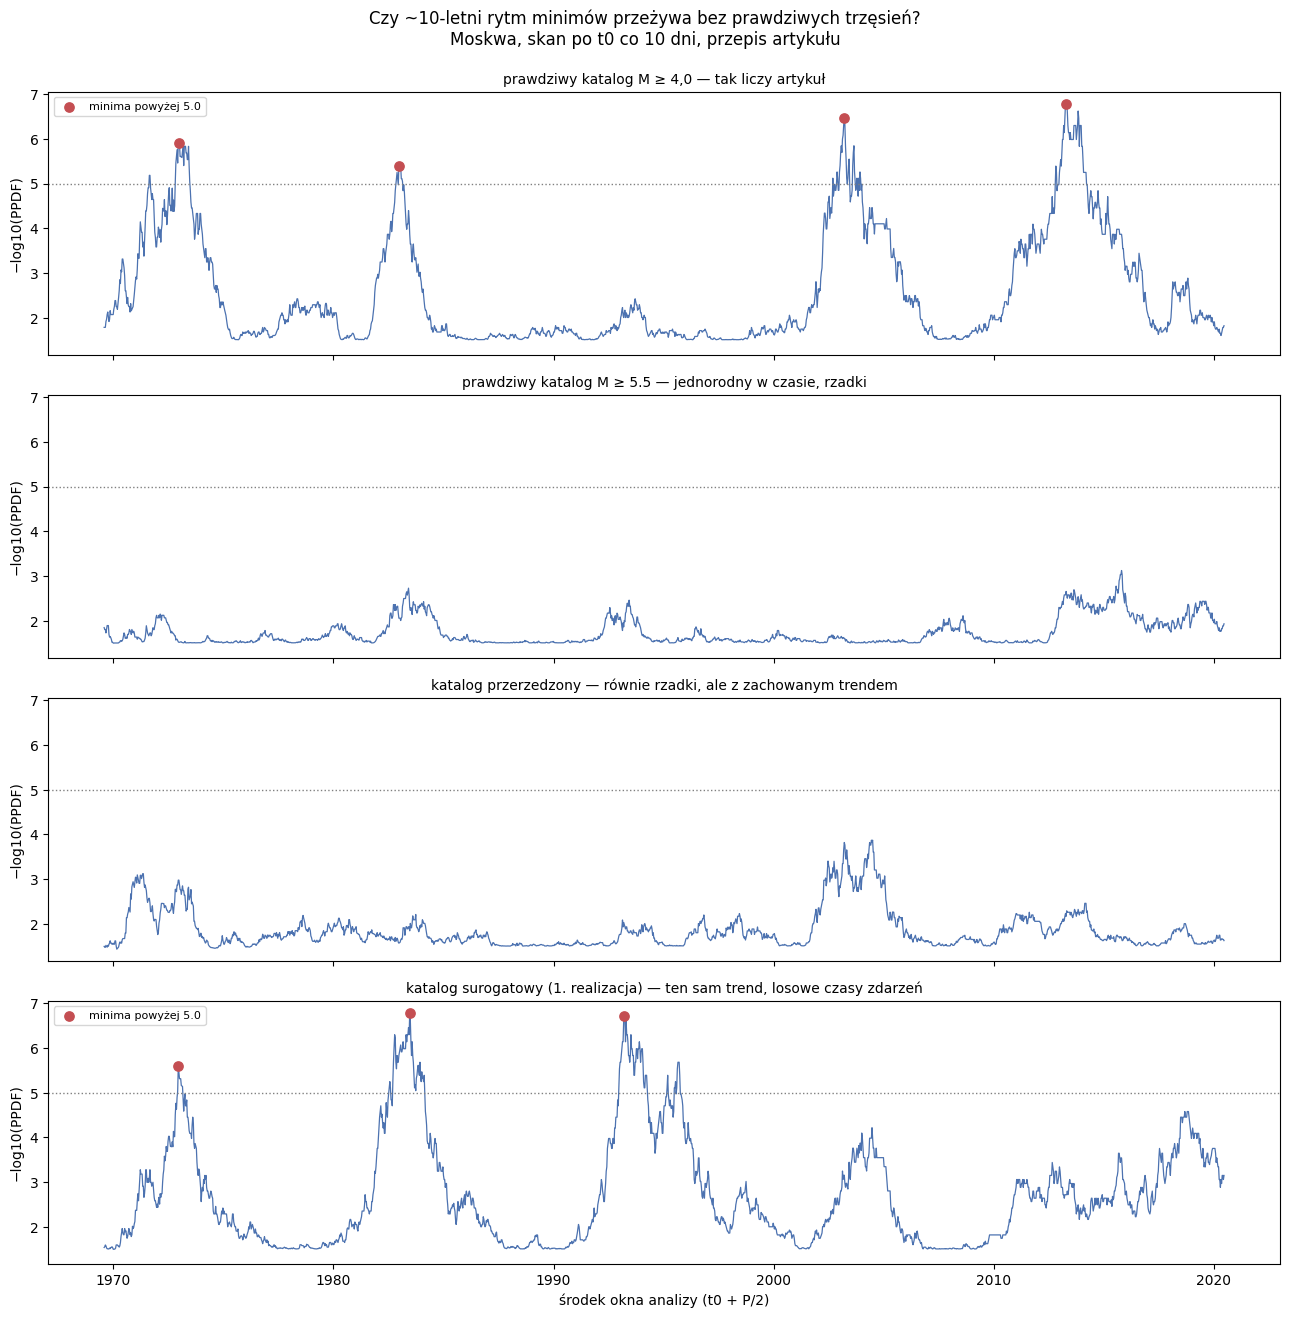

In [17]:
# Wykres 2 (panele, w kazdym jedno kodowanie: wysokosc krzywej w funkcji czasu):
# te same osie dla wszystkich rysowanych wersji, zeby porownanie bylo
# bezposrednie. Rysujemy cztery: prawdziwy M>=4.0, prawdziwy przy progu
# kompletnosci, przerzedzony i PIERWSZA realizacje surogatu; pozostale
# realizacje sa w tabeli w ostatniej komorce - na wykresie chodzi o ksztalt
# krzywej, a nie o statystyke po realizacjach.
# Konwencja Fig.4 artykulu: os X to SRODEK okna (t0 + P/2).
tytuly = {
    "prawdziwy_M4": "prawdziwy katalog M ≥ 4,0 — tak liczy artykuł",
    f"prawdziwy_M{M_KOMPLETNY}": f"prawdziwy katalog M ≥ {M_KOMPLETNY} — jednorodny w czasie, rzadki",
    "przerzedzony_M4": "katalog przerzedzony — równie rzadki, ale z zachowanym trendem",
    NAZWY_SUROGATOW[0]: "katalog surogatowy (1. realizacja) — ten sam trend, losowe czasy zdarzeń",
}
WERSJE_NA_WYKRES = [w for w in WERSJE if w[0] in tytuly]
fig, axes = plt.subplots(len(WERSJE_NA_WYKRES), 1, figsize=(13, 3.3 * len(WERSJE_NA_WYKRES)),
                         sharex=True, sharey=True)
for ax, (nazwa, _, _) in zip(axes, WERSJE_NA_WYKRES):
    k = skan[skan["wersja"] == nazwa].sort_values("t0")
    srodek = k["t0"] + pd.Timedelta(days=P_DAYS / 2)
    ax.plot(srodek, k["neglog10_PPDF"], lw=0.9, color="#4C72B0")
    piki = znalezione[nazwa]
    if len(piki):
        ax.scatter(piki["t0"] + pd.Timedelta(days=P_DAYS / 2), piki["neglog10_PPDF"],
                   s=45, color="#C44E52", zorder=5, label=f"minima powyżej {PROG_WYSOKOSCI}")
        ax.legend(fontsize=8, loc="upper left")
    ax.axhline(PROG_WYSOKOSCI, color="gray", ls=":", lw=1)
    ax.set_ylabel("−log10(PPDF)")
    ax.set_title(tytuly[nazwa], fontsize=10)
axes[-1].set_xlabel("środek okna analizy (t0 + P/2)")
fig.suptitle("Czy ~10-letni rytm minimów przeżywa bez prawdziwych trzęsień?\n"
             "Moskwa, skan po t0 co 10 dni, przepis artykułu", y=0.995)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/surogat_skan_mosc.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/surogat_skan_mosc.png")


Zapisano ../results/surogat_co_zachowuje.png
Kontrola liczbowa: laczna liczba zdarzen prawdziwy=507920, surogat=507920; najwieksza roznica roczna=0
W roku 2011: najwiecej zdarzen na dobe prawdziwy=565, surogat=70


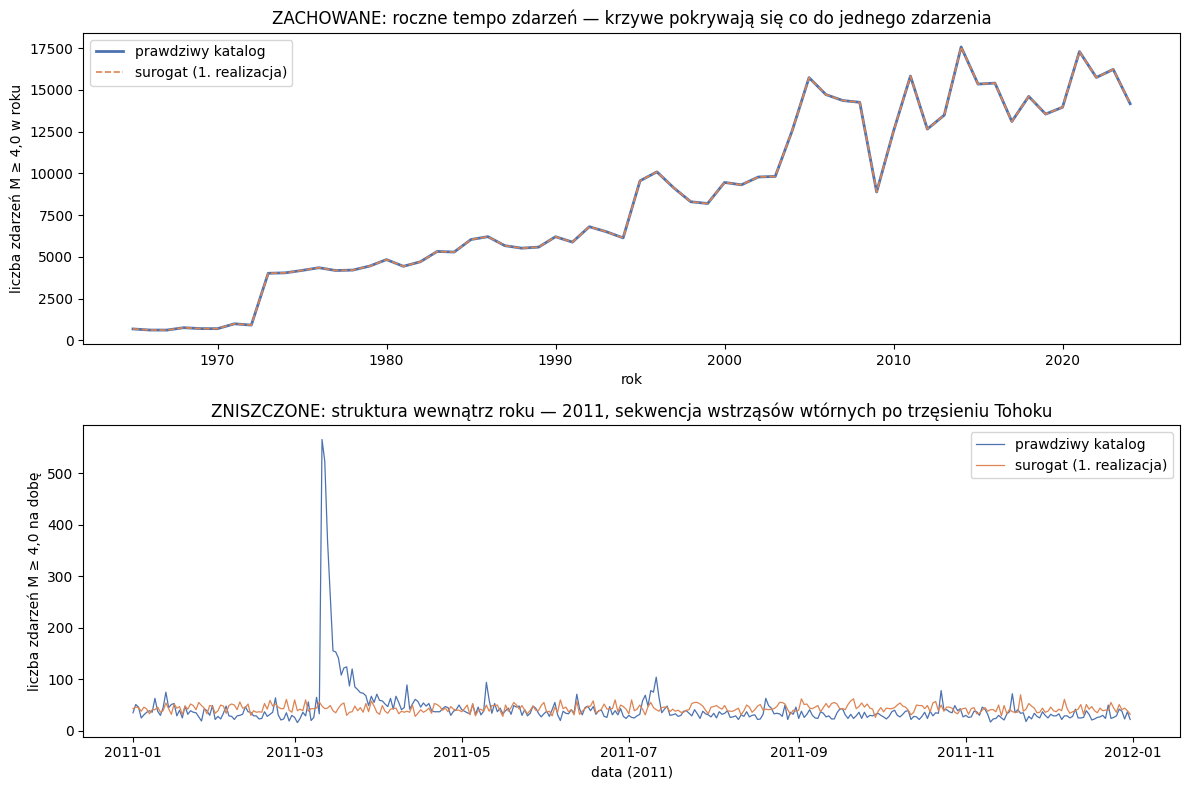

In [18]:
# Wykres 3 (dwa panele, w kazdym jedno kodowanie: wysokosc krzywej w funkcji
# czasu): CO SUROGAT ZACHOWUJE, A CO NISZCZY. To jest wykres objasniajacy sama
# metode - bez niego "katalog surogatowy" jest pustym slowem.
#   panel gorny: roczna liczba zdarzen. Krzywe musza sie POKRYWAC co do jednego
#     zdarzenia - to jest wlasnie zachowany trend detekcyjny.
#   panel dolny: zblizenie na jeden rok, tempo dzienne. Tu krzywe musza sie
#     RADYKALNIE roznic - prawdziwy katalog ma ogromne piki po wielkich
#     trzesieniach (sekwencje wstrzasow wtornych), surogat jest plaski, bo czasy
#     zdarzen sa w nim losowe w obrebie roku.
ROK_ZBLIZENIA = 2011  # rok trzesienia Tohoku (11 marca) - najwyrazniejsza
                      # sekwencja wstrzasow wtornych w calym katalogu

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

rocznie_p = katalog.groupby(katalog["time"].dt.year).size().reindex(LATA_PELNE)
rocznie_s = surogaty[0].groupby(surogaty[0]["time"].dt.year).size().reindex(LATA_PELNE)
ax1.plot(rocznie_p.index, rocznie_p.values, lw=2.0, color="#4C72B0",
         label="prawdziwy katalog")
ax1.plot(rocznie_s.index, rocznie_s.values, lw=1.2, ls="--", color="#DD8452",
         label="surogat (1. realizacja)")
ax1.set_xlabel("rok")
ax1.set_ylabel("liczba zdarzeń M ≥ 4,0 w roku")
ax1.set_title("ZACHOWANE: roczne tempo zdarzeń — krzywe pokrywają się co do jednego zdarzenia")
ax1.legend()

okno_p = katalog[katalog["time"].dt.year == ROK_ZBLIZENIA].set_index("time")
okno_s = surogaty[0][surogaty[0]["time"].dt.year == ROK_ZBLIZENIA].set_index("time")
ax2.plot(okno_p.resample("D").size(), lw=0.9, color="#4C72B0", label="prawdziwy katalog")
ax2.plot(okno_s.resample("D").size(), lw=0.9, color="#DD8452", label="surogat (1. realizacja)")
ax2.set_xlabel(f"data ({ROK_ZBLIZENIA})")
ax2.set_ylabel("liczba zdarzeń M ≥ 4,0 na dobę")
ax2.set_title(f"ZNISZCZONE: struktura wewnątrz roku — {ROK_ZBLIZENIA}, "
              "sekwencja wstrząsów wtórnych po trzęsieniu Tohoku")
ax2.legend()

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/surogat_co_zachowuje.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/surogat_co_zachowuje.png")
print(f"Kontrola liczbowa: laczna liczba zdarzen prawdziwy={len(katalog)}, "
      f"surogat={len(surogaty[0])}; najwieksza roznica roczna="
      f"{(rocznie_s - rocznie_p).abs().max():.0f}")
print(f"W roku {ROK_ZBLIZENIA}: najwiecej zdarzen na dobe prawdziwy="
      f"{okno_p.resample('D').size().max()}, surogat={okno_s.resample('D').size().max()}")


Zapisano ../results/surogat_mechanizm_A.png
  prawdziwy  udzial binow z A>0 w pierwszej polowie okna: 0.036, w drugiej: 0.961
  surogat    udzial binow z A>0 w pierwszej polowie okna: 0.024, w drugiej: 0.973
  (dla ciagu bez trendu obie liczby bylyby bliskie 0,5)


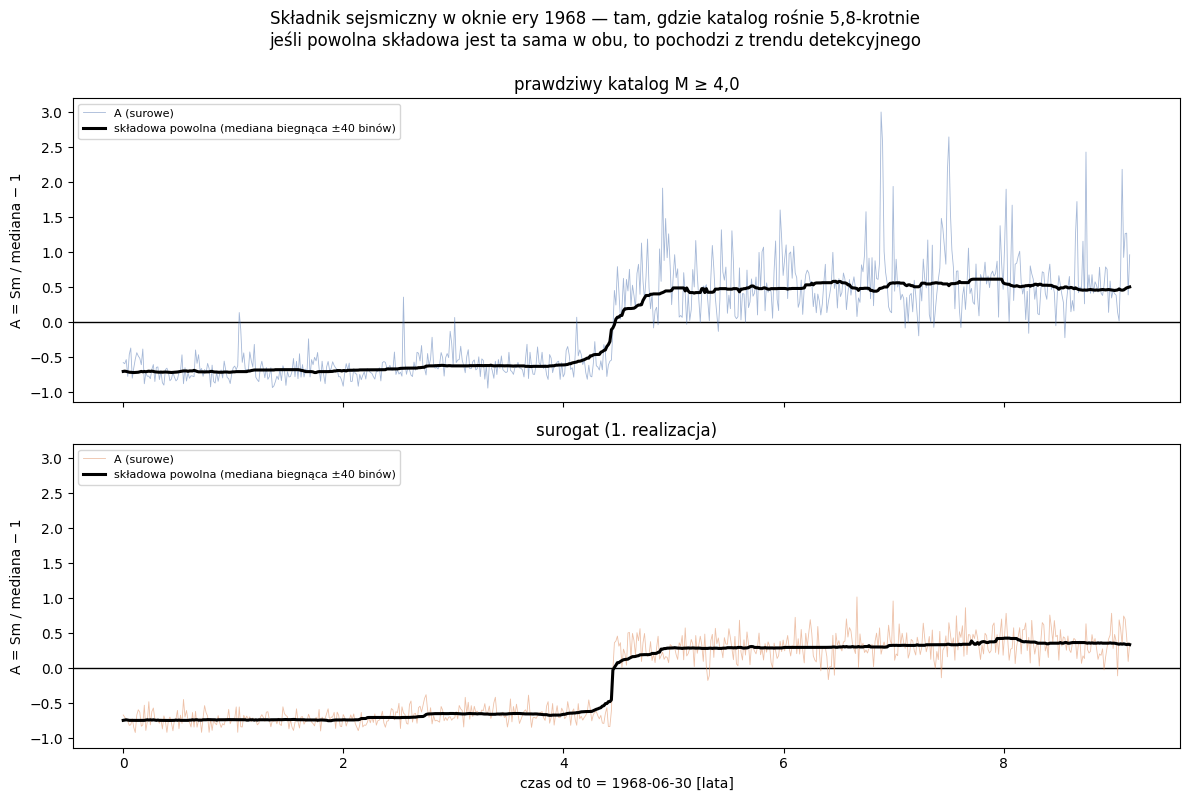

In [19]:
# Wykres 4 (dwa panele, w kazdym jedno kodowanie: wartosc w funkcji numeru
# kosza): MECHANIZM. Skladnik A = Sm/mediana(Sm) - 1 w oknie ery 1968, czyli w
# tym, ktore zawiera najstromszy trend detekcyjny w calym katalogu (5,77x, patrz
# komorka z przyrostem w erach). Rysujemy go osobno dla katalogu prawdziwego i
# dla surogatu.
#
# Czego szukamy: czy POWOLNA skladowa A jest w obu przypadkach taka sama. Jesli
# tak, to znaczy, ze bierze sie z trendu detekcyjnego, a nie z prawdziwej
# sejsmicznosci - bo surogat prawdziwej sejsmicznosci nie ma. Skladowa powolna
# rysowana jest jako mediana biegnaca +-40 binow (ta sama, ktorej uzywa
# 20260901c.ipynb).
ERA_MECHANIZM = 1968
t0_mech = centra[ERA_MECHANIZM]
N_BIN = P_DAYS // D_DAYS


def sm_okna(kat, t0, prog=4.0):
    eq_lok = kat[kat["mag"] >= prog].set_index("time")["mag"].sort_index()
    edges = (pd.date_range(t0, periods=N_BIN + 1, freq=pd.Timedelta(days=D_DAYS))
             + pd.Timedelta(days=DT_DAYS))
    w = eq_lok[(eq_lok.index >= edges[0]) & (eq_lok.index < edges[-1])]
    cats = pd.cut(w.index, edges, right=False)
    return w.groupby(cats, observed=False).sum().reindex(
        cats.categories, fill_value=0.0).to_numpy()[1:]


osx = np.arange(N_BIN - 1) * D_DAYS / 365.25
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)
for ax, (nazwa, kat, kolor) in zip(axes, [
        ("prawdziwy katalog M ≥ 4,0", katalog, "#4C72B0"),
        ("surogat (1. realizacja)", surogaty[0], "#DD8452")]):
    Sm = sm_okna(kat, t0_mech)
    A = Sm / np.nanmedian(Sm) - 1
    wolna = pd.Series(A).rolling(81, center=True, min_periods=27).median().to_numpy()
    ax.axhline(0, color="black", lw=1)
    ax.plot(osx, A, lw=0.6, color=kolor, alpha=0.5, label="A (surowe)")
    ax.plot(osx, wolna, lw=2.2, color="black",
            label="składowa powolna (mediana biegnąca ±40 binów)")
    ax.set_ylabel("A = Sm / mediana − 1")
    ax.set_title(nazwa)
    ax.legend(fontsize=8, loc="upper left")
axes[-1].set_xlabel(f"czas od t0 = {t0_mech.date()} [lata]")
fig.suptitle(f"Składnik sejsmiczny w oknie ery {ERA_MECHANIZM} — tam, gdzie katalog "
             "rośnie 5,8-krotnie\n"
             "jeśli powolna składowa jest ta sama w obu, to pochodzi z trendu detekcyjnego",
             y=0.995)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/surogat_mechanizm_A.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/surogat_mechanizm_A.png")
for nazwa, kat in [("prawdziwy", katalog), ("surogat", surogaty[0])]:
    Sm = sm_okna(kat, t0_mech)
    A = Sm / np.nanmedian(Sm) - 1
    print(f"  {nazwa:10s} udzial binow z A>0 w pierwszej polowie okna: "
          f"{(A[:len(A) // 2] > 0).mean():.3f}, w drugiej: {(A[len(A) // 2:] > 0).mean():.3f}")
print("  (dla ciagu bez trendu obie liczby bylyby bliskie 0,5)")


Zapisano ../results/surogat_rozklad_skanu.png

Frakcja punktow skanu powyzej wybranych poziomow:
wersja                     >3       >4       >5       >6
prawdziwy_M4           0.2867   0.1625   0.0602   0.0140
prawdziwy_M5.5         0.0022   0.0000   0.0000   0.0000
przerzedzony_M4        0.0425   0.0000   0.0000   0.0000
surogat1_M4            0.3077   0.1404   0.0667   0.0140
surogat2_M4            0.4793   0.3034   0.1124   0.0425
surogat3_M4            0.4180   0.2275   0.0990   0.0328


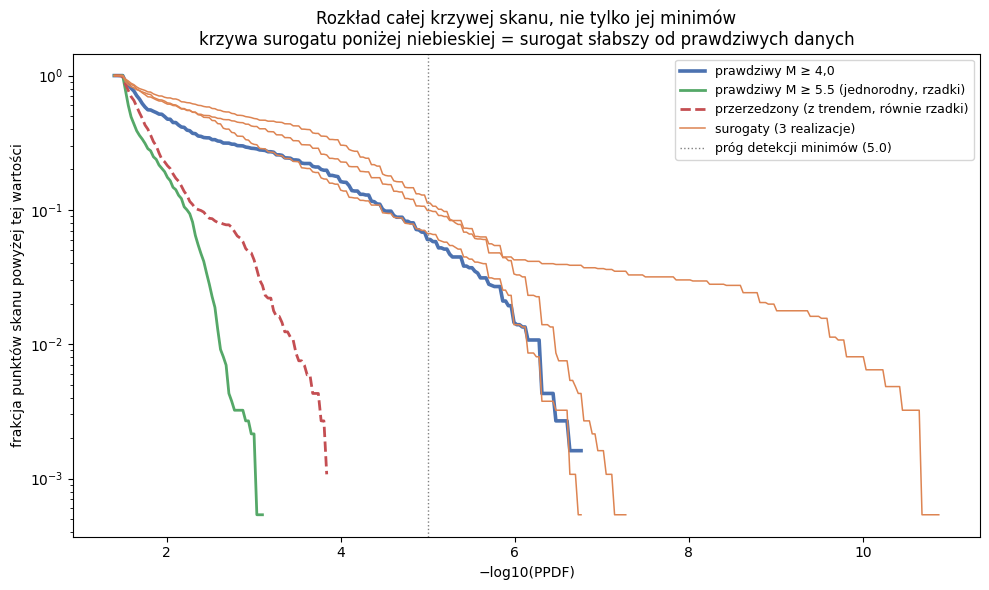

In [20]:
# Wykres 5 (jedno kodowanie: wysokosc krzywej): ROZKLAD CALEGO SKANU, nie tylko
# jego minimow. Dla kazdej wersji katalogu rysujemy frakcje punktow skanu
# przekraczajacych dana wartosc -log10 PPDF (funkcja przezycia, os Y
# logarytmiczna). Detekcja minimow patrzy tylko na ogon tego rozkladu i na
# arbitralny prog 5,0; ten wykres pokazuje CALY rozklad, wiec nie da sie go
# zmylic wyborem progu.
#
# Czego szukamy: czy krzywe surogatow leza PONIZEJ krzywej prawdziwego katalogu
# (czyli surogaty sa slabsze), czy na niej / powyzej (czyli nie sa).
poziomy = np.linspace(1.4, 11.0, 300)

fig, ax = plt.subplots(figsize=(10, 6))
style = {
    "prawdziwy_M4": dict(color="#4C72B0", lw=2.6, label="prawdziwy M ≥ 4,0"),
    f"prawdziwy_M{M_KOMPLETNY}": dict(color="#55A868", lw=2.0,
                                      label=f"prawdziwy M ≥ {M_KOMPLETNY} (jednorodny, rzadki)"),
    "przerzedzony_M4": dict(color="#C44E52", lw=2.0, ls="--",
                            label="przerzedzony (z trendem, równie rzadki)"),
}
for nazwa, _, _ in WERSJE:
    k = skan[skan["wersja"] == nazwa]["neglog10_PPDF"].dropna().to_numpy()
    y = np.array([(k > x).mean() for x in poziomy])
    if nazwa in style:
        ax.semilogy(poziomy, np.where(y > 0, y, np.nan), **style[nazwa])
    else:
        ax.semilogy(poziomy, np.where(y > 0, y, np.nan), color="#DD8452", lw=1.1,
                    label="surogaty (3 realizacje)" if nazwa == NAZWY_SUROGATOW[0] else None)
ax.axvline(PROG_WYSOKOSCI, color="gray", ls=":", lw=1,
           label=f"próg detekcji minimów ({PROG_WYSOKOSCI})")
ax.set_xlabel("−log10(PPDF)")
ax.set_ylabel("frakcja punktów skanu powyżej tej wartości")
ax.set_title("Rozkład całej krzywej skanu, nie tylko jej minimów\n"
             "krzywa surogatu poniżej niebieskiej = surogat słabszy od prawdziwych danych")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/surogat_rozklad_skanu.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/surogat_rozklad_skanu.png")
print()
print("Frakcja punktow skanu powyzej wybranych poziomow:")
print(f"{'wersja':20s} {'>3':>8s} {'>4':>8s} {'>5':>8s} {'>6':>8s}")
for nazwa, _, _ in WERSJE:
    k = skan[skan["wersja"] == nazwa]["neglog10_PPDF"].dropna()
    print(f"{nazwa:20s} " + " ".join(f"{(k > p).mean():8.4f}" for p in [3, 4, 5, 6]))


In [21]:
# Podsumowanie z regulami odczytu ustalonymi z gory.
print("=" * 72)
print("KATALOG JAKO ZRODLO EFEKTU - PODSUMOWANIE")
print("=" * 72)
print()
print("Reguly odczytu skanu surogatowego, ustalone przed zobaczeniem wyniku:")
print("  A. Surogat NIE produkuje minimow powyzej progu  ->  rytm wymaga")
print("     prawdziwej struktury czasowej trzesien; hipoteza artefaktu")
print("     trendowego zostaje OBALONA w tej postaci.")
print("  B. Surogat produkuje minima podobnej glebokosci i o podobnych")
print("     odstepach  ->  rytm da sie wyprodukowac z samego trendu")
print("     detekcyjnego i cyklu slonecznego, bez zadnego zwiazku CR-EQ.")
print("     To jest mechanizm pokazany konstrukcyjnie, nie wywnioskowany.")
print("  C. Surogat produkuje minima, ale wyraznie plytsze  ->  czesc efektu")
print("     jest trendowa, czesc nie; wtedy interesuje nas RESZTA, czyli")
print("     roznica miedzy krzywa prawdziwa a surogatowa.")
print()
for nazwa, _, _ in WERSJE:
    k = skan[skan["wersja"] == nazwa]
    piki = znalezione[nazwa]
    print(f"{nazwa:20s} minimow: {len(piki):2d}, najglebsze: "
          f"{k['neglog10_PPDF'].max():6.2f}, mediana krzywej: "
          f"{k['neglog10_PPDF'].median():5.2f}, mediana N_valid: {k['N_valid'].median():5.0f}")
print()
print(f"Rozrzut miedzy {N_SUROGATOW} realizacjami surogatu (to jest liczba, ktora")
print("decyduje - jedna realizacja nic by nie mowila):")
liczby = [len(znalezione[n]) for n in NAZWY_SUROGATOW]
glebokosci = [skan[skan["wersja"] == n]["neglog10_PPDF"].max() for n in NAZWY_SUROGATOW]
print(f"  liczba minimow powyzej progu: {liczby}")
print(f"  najglebsze -log10 PPDF:       {[round(g, 2) for g in glebokosci]}")
print(f"  dla porownania prawdziwy M4:  {len(znalezione['prawdziwy_M4'])} minimow, "
      f"najglebsze {skan[skan.wersja == 'prawdziwy_M4']['neglog10_PPDF'].max():.2f}")
print()
print("KONTROLA 'jednorodnosc czy rzadkosc': katalog przerzedzony ma tyle samo")
print("zdarzen co katalog przy progu kompletnosci, ale zachowuje trend detekcyjny.")
n_kompl = len(znalezione[f"prawdziwy_M{M_KOMPLETNY}"])
n_przerz = len(znalezione["przerzedzony_M4"])
print(f"  M>={M_KOMPLETNY} (jednorodny, rzadki): {n_kompl} minimow")
print(f"  przerzedzony (z trendem, rownie rzadki): {n_przerz} minimow")
if n_przerz > n_kompl:
    print("  -> minima przezywaja przerzedzenie, ale nie przezywaja usuniecia trendu:")
    print("     zanik przy progu kompletnosci wynika z JEDNORODNOSCI, nie z rzadkosci.")
elif n_przerz == 0 and n_kompl == 0:
    print("  -> obie wersje bez minimow: NIE DA SIE rozstrzygnac, czy decyduje")
    print("     jednorodnosc czy rzadkosc katalogu. Wynik dla M>=5.5 traci wtedy sile")
    print("     dowodowa i trzeba to powiedziec wprost.")
else:
    print("  -> wynik posredni, wymaga osobnego omowienia")
print()
print("GDZIE SZUKAC ODPOWIEDZI, JESLI TA KONTROLA WYSZLA NIEROZSTRZYGAJACO:")
print("podniesienie progu magnitudy NIE DA SIE oddzielic od przerzedzenia -")
print("kazdy sposob usuniecia trendu z katalogu przez wyrzucanie zdarzen")
print("zmniejsza tez ich gestosc, bo zdarzen nie da sie dolozyc. Test o")
print("zachowanej gestosci zostal juz jednak zrobiony w 20260901c.ipynb:")
print("wariant 'tylko_EQ_n40' usuwa trend po stronie sejsmicznej medianą")
print("biegnaca, przy PELNYM katalogu M>=4.0 i niezmienionej liczbie zdarzen -")
print("i tam kontrast minima-tlo spada z +6,29 do +0,49. To jest wlasciwa")
print("odpowiedz na pytanie 'czy to trend po stronie trzesien', wolna od")
print("mylacego wplywu gestosci katalogu.")
print()
print("ZASTRZEZENIA:")
print(f"- Zakres skanu konczy sie na t0 = {T0_KONIEC.date()}, bo dla pozniejszych t0")
print(f"  okno {P_DAYS}+{DT_DAYS} dni wychodzi poza koniec katalogu. Bez tego")
print("  przyciecia ostatnie ~18% krzywej mialo polowe koszy pustych i dawalo")
print("  sztuczne struktury (blad pierwszej wersji tego notebooka, 01.09).")
print("- Skan jest zgrubny (krok 10 dni zamiast 6h), wiec glebokosci minimow sa")
print("  systematycznie ZANIZONE wzgledem pelnego skanu - siatka rzadziej trafia")
print("  w dno. Porownywac wersje MIEDZY SOBA, nie z liczbami z 26.08/31.08.")
print("- Surogat niszczy takze grupowanie wstrzasow wtornych, ktore jest realna")
print("  struktura sejsmiczna. Jesli minima znikna, nie dowodzi to jeszcze zwiazku")
print("  z CR - moze chodzic o autokorelacje samego katalogu.")
print("- Prog kompletnosci obniza liczbe zdarzen na kosz, wiec przy M>=5.5 rosnie")
print("  udzial koszy pustych (Sm=0), ktore wypadaja z maski waznosci. Kolumna")
print("  N_valid mowi, ile koszy faktycznie zostalo - patrz tabela wyzej.")


KATALOG JAKO ZRODLO EFEKTU - PODSUMOWANIE

Reguly odczytu skanu surogatowego, ustalone przed zobaczeniem wyniku:
  A. Surogat NIE produkuje minimow powyzej progu  ->  rytm wymaga
     prawdziwej struktury czasowej trzesien; hipoteza artefaktu
     trendowego zostaje OBALONA w tej postaci.
  B. Surogat produkuje minima podobnej glebokosci i o podobnych
     odstepach  ->  rytm da sie wyprodukowac z samego trendu
     detekcyjnego i cyklu slonecznego, bez zadnego zwiazku CR-EQ.
     To jest mechanizm pokazany konstrukcyjnie, nie wywnioskowany.
  C. Surogat produkuje minima, ale wyraznie plytsze  ->  czesc efektu
     jest trendowa, czesc nie; wtedy interesuje nas RESZTA, czyli
     roznica miedzy krzywa prawdziwa a surogatowa.

prawdziwy_M4         minimow:  4, najglebsze:   6.79, mediana krzywej:  1.96, mediana N_valid:   667
prawdziwy_M5.5       minimow:  0, najglebsze:   3.12, mediana krzywej:  1.59, mediana N_valid:   661
przerzedzony_M4      minimow:  0, najglebsze:   3.87, mediana 